# 特征工程实验

本 Notebook 在已经校准的 CatBoost 基准上开展受控特征工程实验，依次说明候选假设、分阶段筛选方法、Fold 1 与完整 5-Fold 结果，并根据增益稳定性和特征复杂度选择第一阶段最终方案。

---

## Table of Contents

1. [实验背景与环境设置](#fe-setup-and-context)
   - 1.1 [实验起点与目标](#fe-experiment-contract)
   - 1.2 [导入依赖与定位项目路径](#fe-imports)
2. [特征目录与假设](#fe-feature-catalog)
3. [受控实验协议与运行方式](#fe-run-experiment)
4. [读取已保存结果](#fe-saved-results)
5. [第一轮：Fold 1 快速筛选](#fe-screening-view)
6. [第二轮：完整 5-Fold 证据](#fe-full-cv)
7. [结果分析与第一阶段决策](#fe-decision-log)
   - 7.1 [Fold 1 告诉了我们什么](#fe-decision-7-1)
   - 7.2 [完整五折结果](#fe-decision-7-2)
   - 7.3 [第一阶段决策](#fe-decision-final)
8. [第一阶段最终模型与提交](#fe10-final-model)
   - 8.1 [准备数据与特征](#fe10-data-preparation)
   - 8.2 [训练全量模型](#fe10-training)
   - 8.3 [生成预测与检查结果](#fe10-prediction)
   - 8.4 [保存提交文件](#fe10-save-submission)
9. [阶段小结与下一步](#fe-next-actions)

---

<a id="fe-setup-and-context" name="fe-setup-and-context"></a>

## 1. 实验背景与环境设置

<a id="fe-experiment-contract" name="fe-experiment-contract"></a>

### 1.1 实验起点与目标

在 `03_cv_experiments.ipynb` 中，CatBoost 已经完成训练预算校准。当前无特征工程基准为：

| 项目 | 结果 |
|---|---:|
| 5-Fold CV AUC | **0.964007 ± 0.000473** |
| 五折最佳轮数均值 | **8,223** |
| Public LB | **0.96538** |

后续实验固定模型、Fold、随机种子和预处理，只改变候选特征。

#### 为什么从屏幕时间结构出发

`02_baseline.ipynb` 的特征重要性显示，`daily_screen_time_hours`、`weekend_screen_time` 与 `social_media_hours` 是主要预测信号。原始时长告诉模型“用了多久”，但未必直接表达以下行为结构：

- 工作日与周末的使用变化；
- 社交、游戏、学习在总屏幕时间中的构成；
- 已记录活动之和与总屏幕时间之间的剩余部分；
- 通知、打开 App 等行为相对单位屏幕时间的强度；
- 睡眠、清醒和离线时间之间的约束。


<a id="fe-imports" name="fe-imports"></a>

### 1.2 导入依赖与定位项目路径

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import FEATURE_SETS, make_experiment_features
from src.selection import CV_STD

RESULTS_DIR = PROJECT_ROOT / "results" / "feature_engineering"
SUMMARY_PATH = RESULTS_DIR / "summary.csv"
FULL_CV_SUMMARY_PATH = RESULTS_DIR / "full_cv_summary.csv"

<a id="fe-feature-catalog" name="fe-feature-catalog"></a>

## 2. 特征目录与假设

特征工程第一阶段围绕以下五个思路作展开。

| 思路 | 实验 | 想回答的问题 |
|---|---|---|
| 缺失模式 | FE01–FE02 | 缺失数量或缺失位置是否本身带有信号？ |
| 时间差与占比 | FE03–FE08 | 相对关系是否比绝对时长更容易被模型利用？ |
| 活动时间构成 | FE09–FE10 | 已知活动总量或未被解释的剩余时间是否有增量信息？ |
| 行为频率 | FE11–FE13 | 单位屏幕时间内的 App 打开和通知强度是否更有效？ |
| 睡眠与离线结构 | FE14–FE18 | 屏幕、睡眠、清醒与离线时间的约束是否有用？ |

FE19 在第一轮之后同时加入 FE09 与 FE10，用来检验两个有效候选是否互补。

In [2]:
FEATURE_INFO = {
    "BASE": (
        "无新增人工特征。",
        "作为候选特征的匹配基线。",
    ),
    "FE01": (
        "num_missing = 每行所有原始特征的缺失数量。",
        "整体缺失程度可能反映填写完整度或样本类型。",
    ),
    "FE02": (
        "对每个原始特征新增 0/1 缺失标记，例如 gender_missing。",
        "缺失位置的组合可能包含原始缺失值之外的信息。",
    ),
    "FE03": (
        "weekend_screen_gap = weekend_screen_time - daily_screen_time_hours。",
        "周末与日常屏幕时间的差值可能反映使用行为变化。",
    ),
    "FE04": (
        "weekend_screen_ratio = weekend_screen_time / daily_screen_time_hours；日常屏幕时间为 0 时记为 NaN。",
        "相对日常水平的周末使用强度可能比绝对时长更有区分度。",
    ),
    "FE05": (
        "social_media_ratio = social_media_hours / daily_screen_time_hours；分母为 0 时记为 NaN。",
        "社交媒体在总屏幕时间中的占比可能补充绝对时长信息。",
    ),
    "FE06": (
        "gaming_ratio = gaming_hours / daily_screen_time_hours；分母为 0 时记为 NaN。",
        "游戏在总屏幕时间中的占比可能刻画使用构成。",
    ),
    "FE07": (
        "work_study_ratio = work_study_hours / daily_screen_time_hours；分母为 0 时记为 NaN。",
        "工作学习占比可能区分功能性与娱乐性使用。",
    ),
    "FE08": (
        "leisure_screen_time = social_media_hours + gaming_hours。",
        "社交与游戏之和可能概括娱乐性屏幕时间。",
    ),
    "FE09": (
        "known_activity_time = social_media_hours + gaming_hours + work_study_hours。",
        "汇总已记录活动时间可能比单个时长更稳定。",
    ),
    "FE10": (
        "unknown_activity_time = daily_screen_time_hours - social_media_hours - gaming_hours - work_study_hours；日常屏幕时间为 0 时记为 NaN。",
        "未被三个已记录活动解释的屏幕时间可能代表其他手机活动。",
    ),
    "FE11": (
        "app_opens_per_screen_hour = app_opens_per_day / daily_screen_time_hours；分母为 0 时记为 NaN。",
        "单位屏幕时间内的 App 打开次数可能刻画使用碎片化。",
    ),
    "FE12": (
        "notifications_per_screen_hour = notifications_per_day / daily_screen_time_hours；分母为 0 时记为 NaN。",
        "单位屏幕时间内的通知数量可能刻画外部打扰强度。",
    ),
    "FE13": (
        "notifications_per_app_open = notifications_per_day / app_opens_per_day。",
        "每次打开 App 对应的通知数可能区分被动与主动使用。",
    ),
    "FE14": (
        "screen_per_awake_hour = daily_screen_time_hours / (24 - sleep_hours)；日常屏幕时间为 0 时记为 NaN。",
        "屏幕时间占清醒时间的比例可能更贴近实际使用负担。",
    ),
    "FE15": (
        "screen_sleep_ratio = daily_screen_time_hours / sleep_hours；日常屏幕时间为 0 时记为 NaN。",
        "屏幕时间与睡眠时间的比例可能反映作息失衡。",
    ),
    "FE16": (
        "leisure_screen_ratio = (social_media_hours + gaming_hours) / daily_screen_time_hours；分母为 0 时记为 NaN。",
        "娱乐性屏幕时间占比可能比单独的社交或游戏占比稳定。",
    ),
    "FE17": (
        "work_leisure_ratio = work_study_hours / (social_media_hours + gaming_hours)；娱乐时间为 0 时记为 NaN。",
        "工作学习与娱乐时间的比例可能描述用途结构。",
    ),
    "FE18": (
        "offline_awake_hours = 24 - sleep_hours - daily_screen_time_hours。",
        "离线清醒时间可能补充睡眠与屏幕时间的联合信息。",
    ),
    "FE19": (
        "同时新增 known_activity_time 与 unknown_activity_time。",
        "已知与未知活动时间可能互补，因此直接与 FE10 比较。",
    ),
}

catalog_rows = []

for experiment_id in FEATURE_SETS:
    definition, hypothesis = FEATURE_INFO[experiment_id]
    catalog_rows.append(
        {
            "实验": experiment_id,
            "定义": definition,
            "假设": hypothesis,
        }
    )

feature_catalog = pd.DataFrame(catalog_rows)
display(feature_catalog)

,实验,定义,假设
0,BASE,无新增人工特征。,作为候选特征的匹配基线。
1,FE01,num_missing = 每行所有原始特征的缺失数量。,整体缺失程度可能反映填写完整度或样本类型。
2,FE02,对每个原始特征新增 0/1 缺失标记，例如 gender_missing。,缺失位置的组合可能包含原始缺失值之外的信息。
3,FE03,weekend_screen_gap = weekend_screen_time - dai...,周末与日常屏幕时间的差值可能反映使用行为变化。
4,FE04,weekend_screen_ratio = weekend_screen_time / d...,相对日常水平的周末使用强度可能比绝对时长更有区分度。
5,FE05,social_media_ratio = social_media_hours / dail...,社交媒体在总屏幕时间中的占比可能补充绝对时长信息。
6,FE06,gaming_ratio = gaming_hours / daily_screen_tim...,游戏在总屏幕时间中的占比可能刻画使用构成。
7,FE07,work_study_ratio = work_study_hours / daily_sc...,工作学习占比可能区分功能性与娱乐性使用。
8,FE08,leisure_screen_time = social_media_hours + gam...,社交与游戏之和可能概括娱乐性屏幕时间。
9,FE09,known_activity_time = social_media_hours + gam...,汇总已记录活动时间可能比单个时长更稳定。


<a id="fe-run-experiment" name="fe-run-experiment"></a>

## 3. 受控实验协议与运行方式

<a id="fe-staged-screening" name="fe-staged-screening"></a>

### 分阶段筛选

1. **Fold 1 初筛**：先运行同协议 `BASE`，再运行一个候选，计算 `Δ = 候选 AUC - 匹配 BASE AUC`。
2. **Fold 2 确认**：只有 Fold 1 达到晋级门槛的候选，才在新 Fold 上确认方向是否仍为正。
3. **完整 5-Fold**：只有通过确认的候选才补齐五折，最终检查平均 Δ、正向 Fold 数量和波动。
4. **消融比较**：组合特征除了与 BASE 比较，还要直接与其中最强的单特征方案比较。

<a id="fe-sigma-threshold" name="fe-sigma-threshold"></a>

### 关于晋级标准 `σ = 0.000473`

`σ` 来自无特征工程模型的五折波动(std)，在此用来评判一个新特征的收益大小。Fold 1 的规则为：

| 相对尺度 | 初筛标签 | 动作 |
|---:|---|---|
| `< 0.25σ` | Reject | 停止 |
| `0.25σ–0.75σ` | Maybe | 暂存，不直接晋级 |
| `0.75σ–1.00σ` | Promote | 运行 Fold 2 |
| `≥ 1.00σ` | Strong candidate | 运行 Fold 2 |

<a id="fe-reproduce" name="fe-reproduce"></a>

### 复现实验
`src.experiment` 支持一次接收多个实验编号。实验会按照命令中的顺序逐个训练，因此先完成匹配 `BASE`，再输入多个 FE：

在项目根目录依次执行：
```bash
# BASE 必须先完成，并保持同一个 Fold 和线程数
python -m src.experiment BASE --fold 1 --thread-count 10

# 下面四个 FE 会按 FE01 → FE02 → FE03 → FE04 顺序训练
python -m src.experiment FE01 FE02 FE03 FE04 --fold 1 --thread-count 10

python -m src.summarize_experiments
```
同一组 BASE 与候选必须保持相同的线程数。

<a id="fe-saved-results" name="fe-saved-results"></a>

## 4. 读取已保存结果

每次单 Fold 实验会保存一个 JSON 文件；汇总脚本将可比较的结果整理为 `summary.csv`。

In [3]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        "未找到 summary.csv；请先完成实验并运行汇总脚本。"
    )

summary_df = pd.read_csv(SUMMARY_PATH)

numeric_cols = [
    "auc",
    "delta_vs_baseline",
    "delta_in_cv_std",
]
summary_df[numeric_cols] = summary_df[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce",
)

<a id="fe-screening-view" name="fe-screening-view"></a>

## 5. 第一轮：Fold 1 快速筛选

Fold 1 的任务是低成本排除明显无效的特征。正 Δ 只代表这个 Fold 上高于 BASE，只有增量达到预设门槛，才值得继续消耗 Fold 2 和完整五折的训练成本。

,实验,AUC,Δ,Δ / σ,阶段判断,下一步
1,FE01,0.963399,0.000009,0.019849,Reject,Stop
2,FE02,0.963430,0.000041,0.086310,Reject,Stop
3,FE03,0.963329,-0.000060,-0.127860,Reject,Stop
4,FE04,0.963352,-0.000038,-0.079401,Reject,Stop
5,FE05,0.963449,0.000060,0.125806,Reject,Stop
6,FE06,0.963389,-0.000000,-0.000607,Reject,Stop
7,FE07,0.963470,0.000081,0.171652,Reject,Stop
8,FE08,0.963373,-0.000017,-0.034967,Reject,Stop
9,FE09,0.963758,0.000369,0.780105,Promote,Run full 5-Fold
10,FE10,0.963985,0.000596,1.259243,Strong candidate,Run full 5-Fold


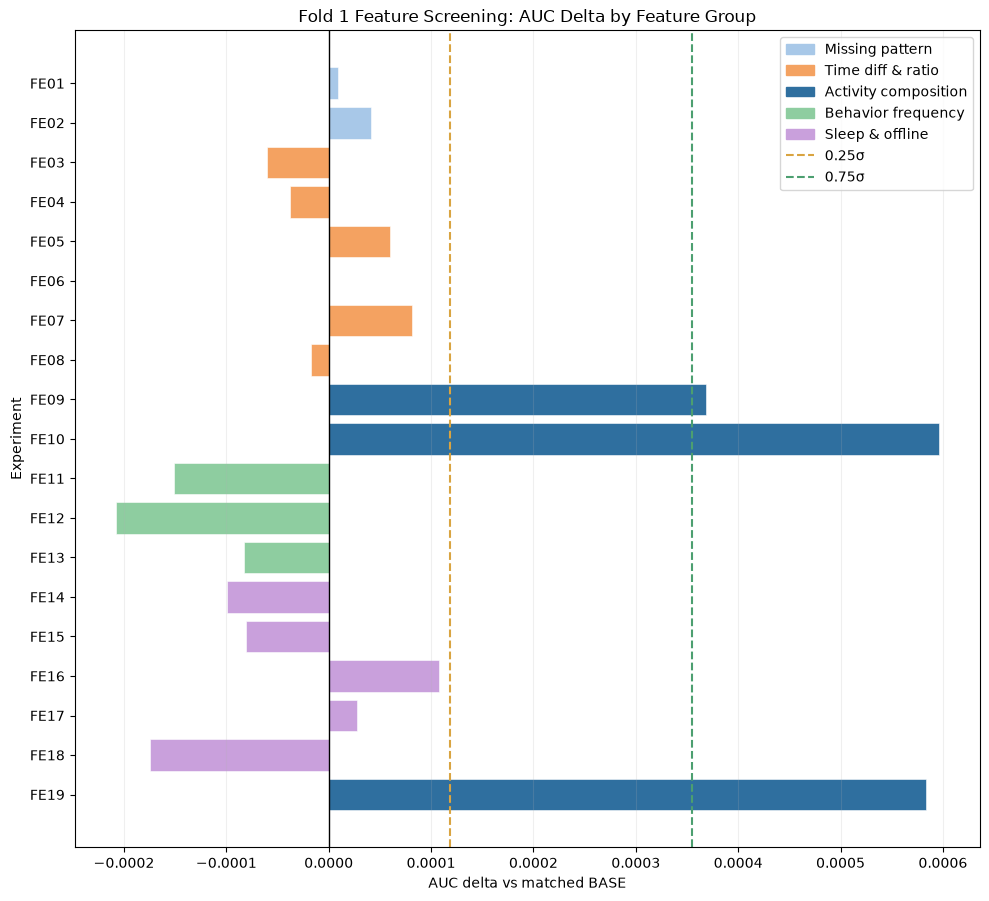

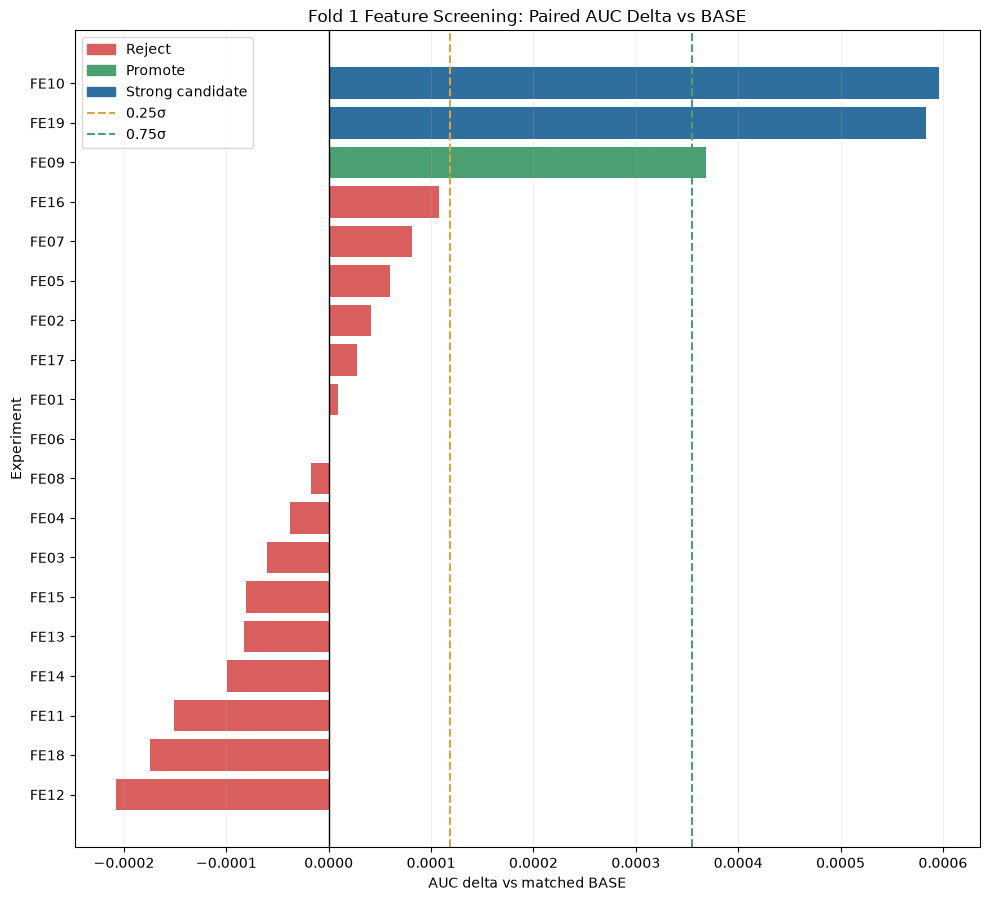

In [4]:
import matplotlib.patches as mpatches

fold1_df = summary_df.loc[
    (summary_df["fold"] == 1)
    & (summary_df["experiment_id"] != "BASE")
].dropna(subset=["delta_vs_baseline"]).copy()

if fold1_df.empty:
    print("当前没有 Fold 1 候选结果。")
else:
    # ── 映射表 ────────────────────────────────────────────────────────────────
    FEATURE_ORDER = [f"FE{i:02d}" for i in range(1, 20)]

    GROUP_MAP = {
        **{f"FE{i:02d}": "Missing pattern"      for i in [1, 2]},
        **{f"FE{i:02d}": "Time diff & ratio"    for i in range(3, 9)},
        **{f"FE{i:02d}": "Activity composition" for i in [9, 10]},
        **{f"FE{i:02d}": "Behavior frequency"   for i in range(11, 14)},
        **{f"FE{i:02d}": "Sleep & offline"      for i in range(14, 19)},
        "FE19": "Activity composition",
    }

    GROUP_COLORS = {
        "Missing pattern":      "#a8c8e8",
        "Time diff & ratio":    "#f4a261",
        "Activity composition": "#2f6f9f",
        "Behavior frequency":   "#8ecda0",
        "Sleep & offline":      "#c9a0dc",
    }

    DECISION_COLORS = {
        "Reject": "#d95f5f", "Maybe": "#d9a441",
        "Promote": "#4c9f70", "Strong candidate": "#2f6f9f",
    }

    LABELS = {
        "experiment_id": "实验", "auc": "AUC",
        "delta_vs_baseline": "Δ", "delta_in_cv_std": "Δ / σ",
        "decision": "阶段判断", "next_step": "下一步",
    }

    # ── 准备数据 ──────────────────────────────────────────────────────────────
    fold1_df = fold1_df.assign(
        group=fold1_df["experiment_id"].map(GROUP_MAP),
        order=fold1_df["experiment_id"].map({f: i for i, f in enumerate(FEATURE_ORDER)}),
    ).sort_values("order")

    # ── 表格：FE 原始顺序 ────────────────────────────────────────────────────
    display(fold1_df[list(LABELS)].rename(columns=LABELS))

    # ── 公共阈值线 ───────────────────────────────────────────────────────────
    def add_reference_lines(ax):
        ax.axvline(0, color="black", linewidth=1)
        ax.axvline(0.25 * CV_STD, color="#d9a441", linestyle="--", label="0.25σ")
        ax.axvline(0.75 * CV_STD, color="#4c9f70", linestyle="--", label="0.75σ")
        ax.set_xlabel("AUC delta vs matched BASE")
        ax.set_ylabel("Experiment")
        ax.grid(axis="x", alpha=0.2)

    # ── 图 1：五大思路分组配色，FE01 在顶 ─────────────────────────────────
    group_plot = fold1_df.iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, max(5, 0.48 * len(fold1_df))))
    ax.barh(
        group_plot["experiment_id"],
        group_plot["delta_vs_baseline"],
        color=group_plot["group"].map(GROUP_COLORS),
        edgecolor="white", linewidth=0.4,
    )
    add_reference_lines(ax)
    ax.set_title("Fold 1 Feature Screening: AUC Delta by Feature Group")

    group_patches = [mpatches.Patch(color=GROUP_COLORS[g], label=g) for g in GROUP_COLORS]
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=group_patches + lines, labels=list(GROUP_COLORS) + labels,
    )
    plt.tight_layout()
    plt.show()

    # ── 图 2：decision 配色，按 Δ 升序 ──────────────────────────────────────
    decision_plot = fold1_df.sort_values("delta_vs_baseline")

    fig, ax = plt.subplots(figsize=(10, max(5, 0.48 * len(fold1_df))))
    ax.barh(
        decision_plot["experiment_id"],
        decision_plot["delta_vs_baseline"],
        color=decision_plot["decision"].map(DECISION_COLORS),
    )
    add_reference_lines(ax)
    ax.set_title("Fold 1 Feature Screening: Paired AUC Delta vs BASE")

    used = {d: DECISION_COLORS[d] for d in decision_plot["decision"].unique()}
    decision_patches = [mpatches.Patch(color=c, label=d) for d, c in used.items()]
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=decision_patches + lines, labels=list(used) + labels,
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

<a id="fe-full-cv" name="fe-full-cv"></a>

## 6. 第二轮：完整 5-Fold 证据

第一轮 FE01–FE18 中，只有 FE09 与 FE10 达到 Fold 1 晋级门槛，并在 Fold 2 继续保持正向，因此补齐完整五折。随后加入 FE19 (The combination of FE09 and FE10) 作为组合消融实验。

,实验,平均 AUC,平均 Δ,正向 Fold,Δ 标准差,线程数
0,FE09,0.964348,0.000341,5,0.000042,10
1,FE10,0.964629,0.000621,5,0.000076,10
2,FE19,0.964651,0.000643,5,0.000092,10


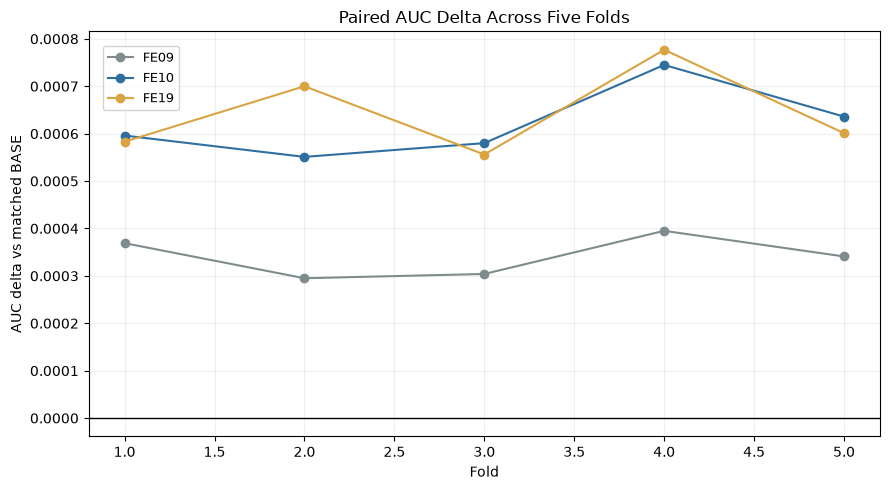

In [5]:
if FULL_CV_SUMMARY_PATH.exists():
    full_cv_df = pd.read_csv(FULL_CV_SUMMARY_PATH)

    full_cv_view = full_cv_df[
        [
            "experiment_id",
            "mean_auc",
            "mean_delta",
            "positive_folds",
            "delta_std",
            "thread_count",
        ]
    ].rename(
        columns={
            "experiment_id": "实验",
            "mean_auc": "平均 AUC",
            "mean_delta": "平均 Δ",
            "positive_folds": "正向 Fold",
            "delta_std": "Δ 标准差",
            "thread_count": "线程数",
        }
    )
    display(full_cv_view)
else:
    full_cv_df = pd.DataFrame()
    print("当前还没有完成五折的特征实验。")

if not summary_df.empty:
    candidate_ids = ["FE09", "FE10", "FE19"]
    fold_delta_df = summary_df.loc[
        summary_df["experiment_id"].isin(candidate_ids),
        ["experiment_id", "fold", "delta_vs_baseline"],
    ].pivot(
        index="fold",
        columns="experiment_id",
        values="delta_vs_baseline",
    )

    if not fold_delta_df.empty:
        ax = fold_delta_df.plot(
            marker="o",
            figsize=(9, 5),
            color={
                "FE09": "#7f8c8d",
                "FE10": "#2f6f9f",
                "FE19": "#d9a441",
            },
        )
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title("Paired AUC Delta Across Five Folds")
        ax.set_xlabel("Fold")
        ax.set_ylabel("AUC delta vs matched BASE")
        ax.grid(alpha=0.2)
        ax.legend(
            loc="upper left",
            bbox_to_anchor=(0.01, 0.98),
            fontsize=9,
            framealpha=0.85,
        )
        plt.tight_layout()
        plt.show()

<a id="fe-decision-log" name="fe-decision-log"></a>

## 7. 结果分析与第一阶段决策

<a id="fe-decision-7-1" name="fe-decision-7-1"></a>

### 7.1 Fold 1 告诉了我们什么

| 特征方向 | 代表结果 | 判断 |
|---|---|---|
| FE01–FE02：缺失信息 | 最好为 FE02 `+0.000041`（`+0.086σ`） | 增量过小，淘汰 |
| FE03–FE08：时间差、占比与简单求和 | 最好为 FE07 `+0.000081`（`+0.172σ`） | 全部未过门槛 |
| FE09–FE10：活动时间构成 | FE09 `+0.000369`；FE10 `+0.000596` | 两者晋级 |
| FE11–FE18：频率、睡眠与离线结构 | 最好为 FE16 `+0.000108`（`+0.229σ`） | 全部未过门槛 |

可见简单比例大多没有带来增益，也许 CatBoost 已经能从原始连续特征中学习不少非线性关系，而人工相除还可能放大低分母样本、缺失值和测量误差，因此新增表达没有提供稳定的额外信息。

FE09 与 FE10 不同。它们把多个时长字段放进同一个"每日时间预算"框架：FE09 表示已经被三个活动字段解释的时间，FE10 则表示总屏幕时间中尚未被这些字段解释的剩余部分。后者可能吸收了数据中没有单独列出的其他手机活动，因此增量更明显。

<a id="fe-decision-7-2" name="fe-decision-7-2"></a>

### 7.2 完整五折结果

| ID | 新增特征 | 平均 AUC | 平均 Δ | 正向 Fold | Δ 标准差 |
|---|---|---:|---:|---:|---:|
| FE09 | `known_activity_time` | `0.964348` | `+0.000341` | 5/5 | `0.000042` |
| FE10 | `unknown_activity_time` | `0.964629` | `+0.000621` | 5/5 | `0.000076` |
| FE19 | FE09 + FE10 | `0.964651` | `+0.000643` | 5/5 | `0.000092` |

三组方案都在 5/5 Fold 上优于各自的 BASE，说明"活动时间构成"是第一阶段最可靠的方向。
| Fold | FE19 − FE10 | 谁更高 |
|---:|---:|---|
| 1 | `-0.000013` | FE10 |
| 2 | `+0.000149` | FE19 |
| 3 | `-0.000024` | FE10 |
| 4 | `+0.000032` | FE19 |
| 5 | `-0.000035` | FE10 |
| 平均 | **`+0.000022`** | 几乎持平 |


FE19 的平均 AUC 虽然略高，但它只在 2/5 Fold 上超过 FE10，平均优势约 `0.000022`。从上面的折线图可以看到，FE19 在平均 Δ 上的微弱优势几乎全部来自 Fold 2 的大幅领先（+0.000149），其余四个 Fold 中 FE19 两次小胜、两次落败，并未呈现出系统性的提升。这让 FE19 的高均值更像是 Fold 2 的随机波动而非新增 `known_activity_time` 带来的稳定增益。同时组合更复杂、配对增量波动也更大。当前证据只能说明两者接近，不能说明加入 FE09 后获得了稳定的额外收益。相比于 FE19 ，FE10 保留了几乎相同的效果，同时让最终方案更简单、结论更清楚。

<a id="fe-decision-final" name="fe-decision-final"></a>

### 7.3 第一阶段决策

- **主线保留 FE10 `unknown_activity_time`**：它是最强的单一新增特征，相对 BASE 平均提升 `+0.000621`，且 5/5 Fold 为正。
- **FE09 作为有效但较弱的旁证**：方向稳定，但增益明显小于 FE10。
- **FE19 记为组合消融，不替代 FE10**：它证明组合没有明显破坏性能，但也没有稳定胜过更简单的 FE10。

因此，第一阶段最终模型使用 **CatBoost + FE10**。这是在效果、稳定性和复杂度之间更稳妥的选择。

<a id="fe10-final-model" name="fe10-final-model"></a>

## 8. 第一阶段最终模型与提交

特征工程第一阶段的最终模型沿用 `03_cv_experiments.ipynb` 的训练方式：先用五折最佳轮数估计训练预算，再在全量训练集上固定轮数训练，不再使用 `eval_set` 或早停。

FE10 五个 Fold 的最佳轮数为 `7506、7274、7399、7438、8190`，均值约为 **7,561**。因此全量训练固定使用 `7,561` 轮，并只增加 `unknown_activity_time`。


<a id="fe10-data-preparation" name="fe10-data-preparation"></a>

### 8.1 准备数据与特征

In [6]:
DATA_DIR = PROJECT_ROOT / "data"
FINAL_EXPERIMENT_ID = "FE10"
FINAL_ITERATIONS_FE10 = 7561

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

X_fe10 = train.drop(columns=["addicted_label", "id"]).copy()
y_fe10 = train["addicted_label"].copy()
X_test_fe10 = test.drop(columns=["id"]).copy()

X_fe10 = make_experiment_features(
    X_fe10,
    FINAL_EXPERIMENT_ID,
)
X_test_fe10 = make_experiment_features(
    X_test_fe10,
    FINAL_EXPERIMENT_ID,
)

cat_cols = [
    "gender",
    "stress_level",
    "academic_work_impact",
]

for col in cat_cols:
    X_fe10[col] = X_fe10[col].fillna("Missing")
    X_test_fe10[col] = X_test_fe10[col].fillna("Missing")

print("训练集特征形状：", X_fe10.shape)
print("测试集特征形状：", X_test_fe10.shape)
print("新增特征：", FEATURE_SETS[FINAL_EXPERIMENT_ID])
print("全量训练轮数：", FINAL_ITERATIONS_FE10)

训练集特征形状： (691369, 13)
测试集特征形状： (296302, 13)
新增特征： ('unknown_activity_time',)
全量训练轮数： 7561


<a id="fe10-training" name="fe10-training"></a>

### 8.2 训练全量模型

In [7]:
final_model_fe10 = CatBoostClassifier(
    iterations=FINAL_ITERATIONS_FE10,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    thread_count=10,
    verbose=500,
    allow_writing_files=False,
)

final_model_fe10.fit(
    X_fe10,
    y_fe10,
    cat_features=cat_cols,
)

0:	total: 164ms	remaining: 20m 37s
500:	total: 51.8s	remaining: 12m 9s
1000:	total: 1m 40s	remaining: 10m 56s
1500:	total: 2m 28s	remaining: 10m
2000:	total: 3m 17s	remaining: 9m 8s
2500:	total: 4m 5s	remaining: 8m 17s
3000:	total: 4m 54s	remaining: 7m 27s
3500:	total: 5m 43s	remaining: 6m 37s
4000:	total: 6m 31s	remaining: 5m 48s
4500:	total: 7m 20s	remaining: 4m 59s
5000:	total: 8m 9s	remaining: 4m 10s
5500:	total: 9m	remaining: 3m 22s
6000:	total: 9m 50s	remaining: 2m 33s
6500:	total: 10m 40s	remaining: 1m 44s
7000:	total: 11m 30s	remaining: 55.2s
7500:	total: 12m 20s	remaining: 5.92s
7560:	total: 12m 26s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, depth=6, eval_metric='AUC', iterations=7561, learning_rate=0.05, loss_function='Logloss', random_seed=42, thread_count=10, verbose=500)

<a id="fe10-prediction" name="fe10-prediction"></a>

### 8.3 生成预测与检查结果

In [8]:
test_pred_fe10 = final_model_fe10.predict_proba(X_test_fe10)[:, 1]

submission_fe10 = sample_submission.copy()
submission_fe10["addicted_label"] = test_pred_fe10

submission_check = pd.DataFrame(
    {
        "检查项": [
            "提交行数",
            "预测缺失数",
            "最小预测概率",
            "最大预测概率",
        ],
        "结果": [
            len(submission_fe10),
            submission_fe10["addicted_label"].isna().sum(),
            submission_fe10["addicted_label"].min(),
            submission_fe10["addicted_label"].max(),
        ],
    }
)

display(submission_fe10.head())
display(submission_check)

feature_importance_fe10 = (
    pd.DataFrame(
        {
            "特征": X_fe10.columns,
            "重要性": final_model_fe10.feature_importances_,
        }
    )
    .sort_values("重要性", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_fe10.head(15))

,id,addicted_label
0,691369,0.999502
1,691370,0.961717
2,691371,0.911448
3,691372,0.989772
4,691373,0.998889


,检查项,结果
0,提交行数,296302.000000
1,预测缺失数,0.000000
2,最小预测概率,0.000027
3,最大预测概率,1.000000


,特征,重要性
0,daily_screen_time_hours,23.007978
1,weekend_screen_time,21.115468
2,social_media_hours,16.045136
3,notifications_per_day,13.633682
4,app_opens_per_day,12.005822
5,work_study_hours,4.228588
6,gaming_hours,3.066566
7,unknown_activity_time,2.929653
8,sleep_hours,2.182419
9,age,1.434141


<a id="fe10-save-submission" name="fe10-save-submission"></a>

### 8.4 保存提交文件

In [11]:
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
SUBMISSION_DIR.mkdir(exist_ok=True)

submission_path = (
    SUBMISSION_DIR
    / "catboost_v3_fe10_7561iter.csv"
)

submission_fe10.to_csv(
    submission_path,
    index=False,
)

print("提交文件已保存到：", submission_path)

提交文件已保存到： /Users/c.c./Developer/Competitions/predicting-smartphone-addiction/submissions/catboost_v3_fe10_7561iter.csv


![CatBoost FE10 Public LB](../images/catboost_v3_fe10_7561_public_lb.png)

<a id="fe-next-actions" name="fe-next-actions"></a>

## 9. 阶段小结与下一步

第一阶段已经完成从"提出候选"到"逐 Fold 筛选"再到"完整五折确认"的闭环。

最重要的结果不是尝试了多少比例，而是确认了一个可复现的方向：**总屏幕时间中未被已知活动解释的剩余部分，比单纯的时长比例更有增量信息。**